# Part 1: Simple Gradient Descent
---

In [1]:
# Step 1: Load dataset, split into training and test sets, and scale features
import numpy as np
from sklearn.datasets import fetch_california_housing

# load California housing price dataset
housing = fetch_california_housing()
x = housing.data
y = housing.target
print(y.mean())
# split into training and test sets, namely 80 percent of examples goes for the training, 20 percent goes for the test set
N_train = int(0.8 * x.shape[0])
x_train = x[:N_train,:]
y_train = y[:N_train]
x_test = x[N_train:,:]
y_test = y[N_train:]

# scale features by removing mean and dividing by the standard deviation
x_bar = np.mean(x_train,axis=0)
x_std = np.std(x_train,axis=0)
x_train_scaled = (x_train - x_bar)/x_std
x_test_scaled = (x_test - x_bar)/x_std

print(x_train_scaled.shape)
print(y_train.shape)
print(x_test_scaled.shape)
print(y_test.shape)

2.068558169089147
(16512, 8)
(16512,)
(4128, 8)
(4128,)


In [2]:
# Step 2: Add intercept terms and initialize parameters
# Note: If you run this step again, please run from step 1 because notebook keeps the value from the previous run
intercept_train = np.ones((N_train,1))
x_train_scaled = np.hstack((intercept_train,x_train_scaled))

intercept_test = np.ones((x.shape[0] - N_train,1))
x_test_scaled = np.hstack((intercept_test,x_test_scaled))

print(x_train_scaled.shape)
print(x_test_scaled.shape)

# init parameters using random values
theta = 0.5 * np.random.randn(x_train_scaled.shape[1])
print(theta)

(16512, 9)
(4128, 9)
[-0.54198932  0.43887784  0.05151832  0.00895493  0.75572346  0.35595795
  0.3760416  -0.07532367  0.8156848 ]


In [3]:
# Step 3: Implement the gradient and the cost function
# In this step, you have to calculate the gradient. You can use the provided formula but the best way is to vectorize
# that formula for efficiency
def compute_gradient(x,y,theta):
    n = len(x)
    return (1.0/n)*np.dot(x.T,(np.dot(x,theta) - y))

def compute_cost(x,y,theta):
    n = len(x)
    return (0.5/n)*np.sum((np.dot(x,theta) - y)**2)

In [4]:
# Step 4: Verify the gradient value
# In this step, you need to verify that the computed gradient is correct. The difference betweet the gradient and the
# approximate gradient should be very small
def approximate_gradient(x,y,theta,epsilon):
    n_features = x.shape[1]
    app_grad = np.zeros(n_features)
    for i in range(n_features):
        epsilon_one_hot = np.zeros(n_features)
        epsilon_one_hot[i] = epsilon
        theta_before = theta - epsilon_one_hot
        theta_after = theta + epsilon_one_hot
        app_grad[i] = (compute_cost(x,y,theta_after) - compute_cost(x,y,theta_before))/(2*epsilon)
    return app_grad

grad = compute_gradient(x_train_scaled,y_train,theta)
epsilon = 1e-4
app_grad = approximate_gradient(x_train_scaled,y_train,theta,epsilon)
print('Sum of gradient squared error: ',np.sum((grad - app_grad)**2))

Sum of gradient squared error:  1.0617008573958105e-22


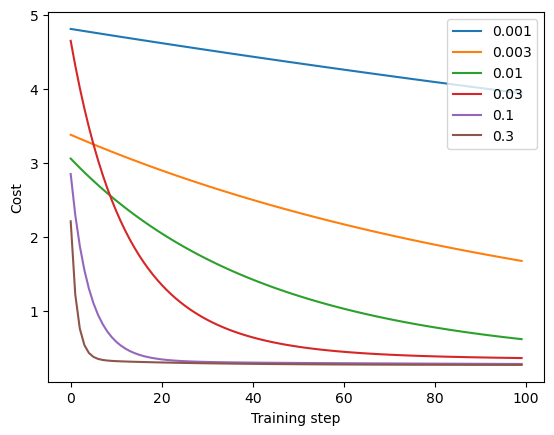

In [5]:
# Step 5: Try gradient descent algorithm with different learning rates
import matplotlib.pyplot as plt
import copy

# try different values for the learning rate
learning_rates = [0.001,0.003,0.01,0.03,0.1,0.3]

# this matrix keeps the learned parameters
theta_matrix = np.zeros((len(learning_rates),x_train_scaled.shape[1]))

# number of training iterations
N_iterations = 100

# prepare to plot
plt.subplot(111)

# calculate cost value and update theta
for indx,alpha in enumerate(learning_rates):
    # keep the cost value for each training step
    J = np.zeros(N_iterations)
    
    # initialize new parameters using random distribution
    theta = 0.5 * np.random.randn(x_train_scaled.shape[1])
    for step in range(N_iterations):
        # update theta
        theta = theta - alpha * compute_gradient(x_train_scaled,y_train,theta)
        
        # calculate the cost on traing set
        J[step] = compute_cost(x_train_scaled,y_train,theta)
        
    # save the value of theta
    theta_matrix[indx,:] = theta
    # plot cost function
    plt.plot(J)
plt.xlabel('Training step')
plt.ylabel('Cost')
plt.legend(('0.001','0.003','0.01','0.03','0.1','0.3'), loc='upper right')
plt.show()

test cost:  0.2842659916816175


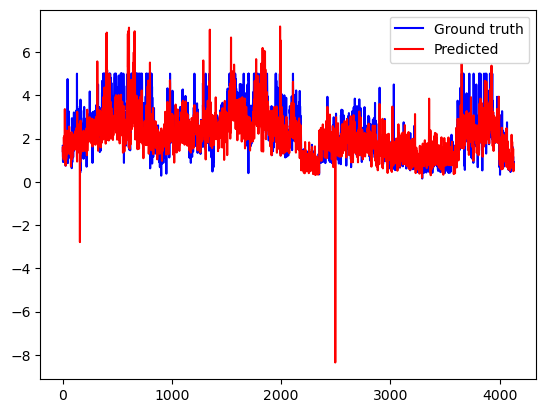

In [6]:
# Step 6: Predict the price of house
theta = theta_matrix[4,:]
predict_price = np.dot(x_test_scaled,theta)

# calculate the cost for the test set
test_cost = compute_cost(x_test_scaled,y_test,theta)
print('test cost: ',test_cost)

# plot the ground truth and the predicted
x_axis = np.linspace(1,len(y_test),len(y_test))
plt.plot(x_axis,y_test,'b',x_axis,predict_price,'r')
plt.legend(('Ground truth','Predicted'))
plt.show()

# Part 2: Gradient Descent with Regularization
---

In [7]:
# Step 1: Load dataset, split into training and test sets, scale features and add intercept terms
import numpy as np
from sklearn.datasets import fetch_california_housing

# load California housing price dataset
housing = fetch_california_housing()
x = housing.data
y = housing.target

# split into training and test sets, namely 80 percent of examples goes for the training, 20 percent goes for the test set
N_train = int(0.8 * x.shape[0])
x_train = x[:N_train,:]
y_train = y[:N_train]
x_test = x[N_train:,:]
y_test = y[N_train:]

# scale features by removing mean and dividing by the standard deviation
x_bar = np.mean(x_train, axis=0)
x_std = np.std(x_train, axis=0)
x_train_scaled = (x_train - x_bar) / x_std
x_test_scaled = (x_test - x_bar) / x_std

print('Number of training samples: ', x_train_scaled.shape[0])
print('Number of testing samples: ', x_test_scaled.shape[0])

# add intercept term
intercept_train = np.ones((N_train, 1))
x_train_scaled = np.hstack((intercept_train, x_train_scaled))
intercept_test = np.ones((x.shape[0] - N_train, 1))
x_test_scaled = np.hstack((intercept_test, x_test_scaled))

print('Training set shape: ', x_train_scaled.shape)
print('Testing set shape: ', x_test_scaled.shape)

Number of training samples:  16512
Number of testing samples:  4128
Training set shape:  (16512, 9)
Testing set shape:  (4128, 9)


In [8]:
# Step 2: Implement the gradient and the cost function with regularization
def compute_regularized_gradient(x, y, theta, lambda_):
    n = x.shape[0]
    return (1.0 / n) * (np.dot(x.T, (np.dot(x, theta) - y)) + lambda_ * theta)

def compute_regularized_cost(x, y, theta, lambda_):
    n = x.shape[0]
    return (0.5 / n) * (np.sum((np.dot(x, theta) - y)**2) + lambda_ * np.sum(theta**2))

def approximate_gradient(x, y, theta, epsilon, lambda_):
    n_features = x.shape[1]
    app_grad = np.zeros(n_features)
    for i in range(n_features):
        epsilon_one_hot = np.zeros(n_features)
        epsilon_one_hot[i] = epsilon
        theta_before = theta - epsilon_one_hot
        theta_after = theta + epsilon_one_hot
        app_grad[i] = (compute_regularized_cost(x, y, theta_after, lambda_) - compute_regularized_cost(x, y, theta_before, lambda_)) / (2 * epsilon)
    return app_grad

# verify your implementation
theta = 0.5 * np.random.randn(x_train_scaled.shape[1])
regularization_term = 1
grad = compute_regularized_gradient(x_train_scaled, y_train, theta, regularization_term)
epsilon = 1e-4
app_grad = approximate_gradient(x_train_scaled, y_train, theta, epsilon, regularization_term)
print('Sum of gradient squared error: ', np.sum((grad - app_grad)**2))

Sum of gradient squared error:  2.6651634803349676e-23


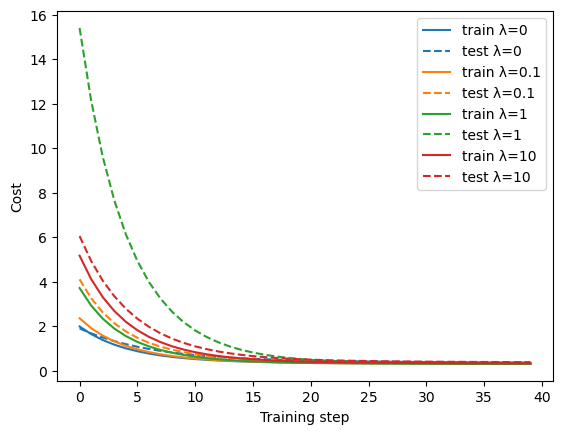

In [9]:
# Step 3: Try gradient descent algorithm with different regularization values
import matplotlib.pyplot as plt

# try different values for the learning rate
alpha = 0.1

# regularization term
lambdas = [0, 0.1, 1, 10]

# this matrix keeps the learned parameters
theta_matrix = np.zeros((len(lambdas), x_train_scaled.shape[1]))

# number of training iterations
N_iterations = 40

# prepare to plot
fig, ax = plt.subplots()
colors = plt.cm.tab10.colors

# calculate cost value and update theta
for indx, lambda_ in enumerate(lambdas):
    # keep the cost value for each training step
    J_train = np.zeros(N_iterations)
    J_test = np.zeros(N_iterations)
    
    # initialize new parameters using random distribution
    theta = 0.5 * np.random.randn(x_train_scaled.shape[1])
    for step in range(N_iterations):
        # update theta
        theta = theta - alpha * compute_regularized_gradient(x_train_scaled, y_train, theta, lambda_)
        
        # calculate the cost on training set
        J_train[step] = compute_regularized_cost(x_train_scaled, y_train, theta, lambda_)
        # calculate cost on the testing set
        J_test[step] = compute_regularized_cost(x_test_scaled, y_test, theta, lambda_)
    # save the value of theta
    theta_matrix[indx, :] = theta

    # use the same color for both training and testing cost
    color = colors[indx]
    ax.plot(J_train, color=color, label=f'train λ={lambda_}')
    ax.plot(J_test, '--', color=color, label=f'test λ={lambda_}')

ax.set_xlabel('Training step')
ax.set_ylabel('Cost')
ax.legend(loc='best')
plt.show()

test cost:  0.35927008150721895


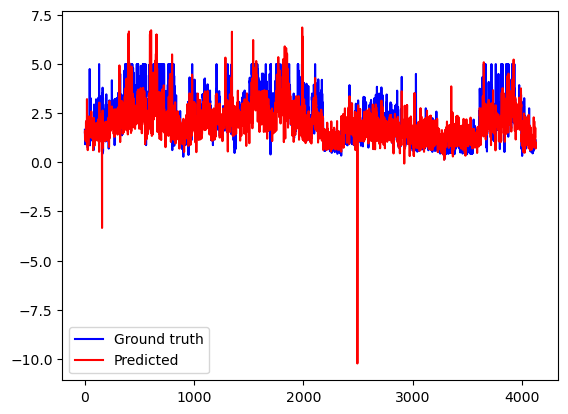

In [10]:
# Step 4: choose lambda
lambda_index = 0
theta = theta_matrix[lambda_index,:]
predict_price = np.dot(x_test_scaled,theta)

# calculate the cost for the test set with lambda=0
test_cost = compute_regularized_cost(x_test_scaled,y_test,theta,0)
print('test cost: ',test_cost)

# plot the ground truth and the predicted
x_axis = np.linspace(1,len(y_test),len(y_test))
plt.plot(x_axis,y_test,'b',x_axis,predict_price,'r')
plt.legend(('Ground truth','Predicted'))
plt.show()

# Part 3: Stochastic and Mini-Batch Gradient Descent
---

In [11]:
# Step 1: Load dataset, split into training and test sets, and scale features
import numpy as np
from sklearn.datasets import fetch_california_housing
np.random.seed(12345)

# load California housing price dataset
housing = fetch_california_housing()
x = housing.data
y = housing.target

# split into training and test sets, namely 80 percent of examples goes for the training, 20 percent goes for the test set
N_train = int(0.8 * x.shape[0])
x_train = x[:N_train,:]
y_train = y[:N_train]
x_test = x[N_train:,:]
y_test = y[N_train:]
# scale features by removing mean and dividing by the standard deviation
x_bar = np.mean(x_train,axis=0)
x_std = np.std(x_train,axis=0)
x_train_scaled = (x_train - x_bar)/x_std
x_test_scaled = (x_test - x_bar)/x_std

print(x_train_scaled.shape)
print(y_train.shape)
print(x_test_scaled.shape)
print(y_test.shape)

(16512, 8)
(16512,)
(4128, 8)
(4128,)


In [12]:
# Step 2: Add intercept terms and initialize parameters
# Note: If you run this step again, please run from step 1 because notebook keeps the value from the previous run
intercept_train = np.ones((N_train,1))
x_train_scaled = np.hstack((intercept_train,x_train_scaled))

intercept_test = np.ones((x.shape[0] - N_train,1))
x_test_scaled = np.hstack((intercept_test,x_test_scaled))

print(x_train_scaled.shape)
print(x_test_scaled.shape)

# init parameters using random values
theta = 0.5 * np.random.randn(x_train_scaled.shape[1])
print(theta)

(16512, 9)
(4128, 9)
[-0.10235383  0.23947167 -0.25971936 -0.27786515  0.98289029  0.69670292
  0.04645394  0.14087308  0.38451128]


In [13]:
# Step 3: Implement the gradient and the cost function
# In this step, you have to calculate the gradient. You can use the provided formula but the best way is to vectorize
# that formula for efficiency
def compute_gradient(x,y,theta):
    n = len(x)
    return (1.0/n)*np.dot(x.T,(np.dot(x,theta) - y))

def compute_cost(x,y,theta):
    n = len(x)
    return (0.5/n)*np.sum((np.dot(x,theta) - y)**2)

print(compute_cost(x_train_scaled,y_train,theta))
print(compute_gradient(x_train_scaled,y_train,theta))

3.5626922702999475
[-2.12302414 -0.62775891 -0.73445493  0.48978497  0.76218808  0.79252296
  0.14708946 -0.08965873  0.37956885]


training cost: 0.268805
test cost: 0.238716


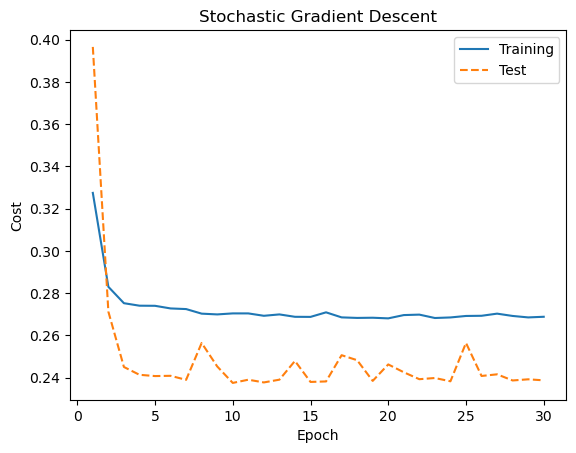

In [14]:
# stochastic gradient descent
import matplotlib.pyplot as plt

# SGD requires a smaller learning rate than batch GD because
# individual sample gradients are noisy and have high variance
learning_rate = 0.0001

num_samples = x_train_scaled.shape[0]
n_epochs = 30

# track cost on training and test sets at the end of each epoch
J_train = np.zeros(n_epochs)
J_test = np.zeros(n_epochs)

# initialize parameters
theta_sgd = 0.5 * np.random.randn(x_train_scaled.shape[1])

for epoch in range(n_epochs):
    # shuffle the training data at the start of each epoch
    indices = np.random.permutation(num_samples)
    x_train_scaled = x_train_scaled[indices, :]
    y_train = y_train[indices]

    for i in range(num_samples):
        # select one training sample
        x_step = x_train_scaled[i].reshape([1, -1])
        y_step = y_train[i]

        # update theta using this single sample
        theta_sgd = theta_sgd - learning_rate * compute_gradient(x_step, y_step, theta_sgd)

    # evaluate cost on training and test sets at the end of the epoch
    J_train[epoch] = compute_cost(x_train_scaled, y_train, theta_sgd)
    J_test[epoch] = compute_cost(x_test_scaled, y_test, theta_sgd)

print('training cost: %f' % J_train[-1])
print('test cost: %f' % J_test[-1])
epochs = range(1, n_epochs + 1)
plt.plot(epochs, J_train, label='Training')
plt.plot(epochs, J_test, '--', label='Test')
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.title('Stochastic Gradient Descent')
plt.legend()
plt.show()

test cost:  0.23871582016913928


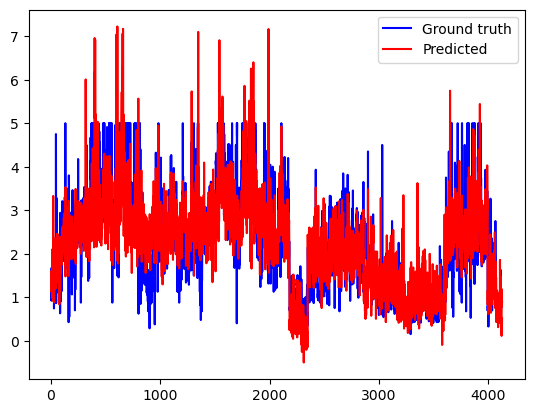

In [15]:
# Predict the price of house
predict_price = np.dot(x_test_scaled,theta_sgd)

# calculate the cost for the test set
test_cost = compute_cost(x_test_scaled,y_test,theta_sgd)
print('test cost: ',test_cost)

# plot the ground truth and the predicted
x_axis = np.linspace(1,len(y_test),len(y_test))
plt.plot(x_axis,y_test,'b',x_axis,predict_price,'r')
plt.legend(('Ground truth','Predicted'))
plt.show()

training cost: 0.298840
test cost: 0.270520


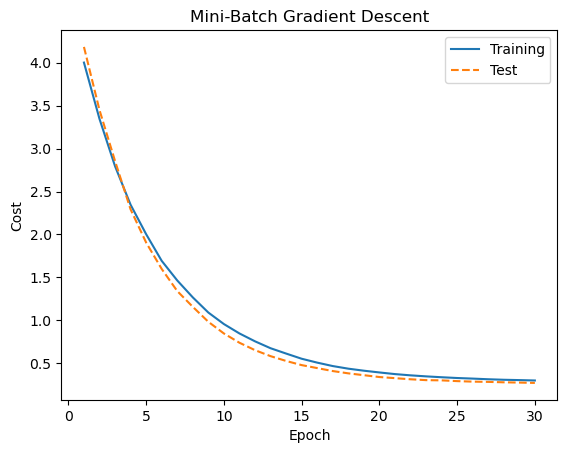

In [16]:
# mini-batch gradient descent
import matplotlib.pyplot as plt

learning_rate = 0.01

num_samples = x_train_scaled.shape[0]
batch_size = int(num_samples / 10)
n_epochs = 30
batches_per_epoch = int(np.ceil(num_samples / batch_size))

# track cost on training and test sets at the end of each epoch
J_train = np.zeros(n_epochs)
J_test = np.zeros(n_epochs)

# initialize parameters
theta_msgd = 0.5 * np.random.randn(x_train_scaled.shape[1])

for epoch in range(n_epochs):
    # shuffle the training data at the start of each epoch
    indices = np.random.permutation(num_samples)
    x_train_scaled = x_train_scaled[indices, :]
    y_train = y_train[indices]

    for b in range(batches_per_epoch):
        start = b * batch_size
        end = min(start + batch_size, num_samples)
        x_batch = x_train_scaled[start:end, :]
        y_batch = y_train[start:end]

        # update theta_msgd using the mini-batch
        theta_msgd = theta_msgd - learning_rate * compute_gradient(x_batch, y_batch, theta_msgd)

    # evaluate cost on training and test sets at the end of the epoch
    J_train[epoch] = compute_cost(x_train_scaled, y_train, theta_msgd)
    J_test[epoch] = compute_cost(x_test_scaled, y_test, theta_msgd)

print('training cost: %f' % J_train[-1])
print('test cost: %f' % J_test[-1])
epochs = range(1, n_epochs + 1)
plt.plot(epochs, J_train, label='Training')
plt.plot(epochs, J_test, '--', label='Test')
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.title('Mini-Batch Gradient Descent')
plt.legend()
plt.show()

test cost:  0.27052011459094993


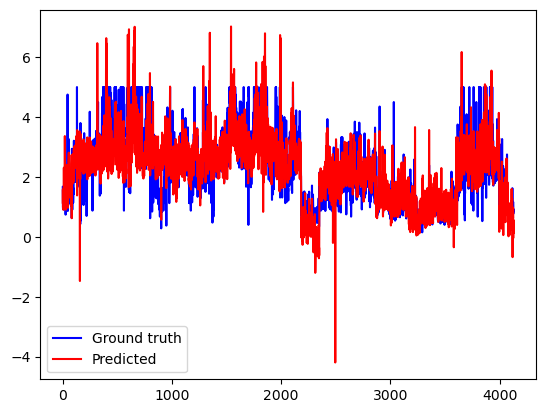

In [17]:
# Predict the price of house
predict_price = np.dot(x_test_scaled,theta_msgd)

# calculate the cost for the test set
test_cost = compute_cost(x_test_scaled,y_test,theta_msgd)
print('test cost: ',test_cost)

# plot the ground truth and the predicted
x_axis = np.linspace(1,len(y_test),len(y_test))
plt.plot(x_axis,y_test,'b',x_axis,predict_price,'r')
plt.legend(('Ground truth','Predicted'))
plt.show()